# Assignment 2: APIs, Data Formats, Databases, and EDA

---

## Submission Instructions

Submit only a link to the folder for Assignment 2 in your personal GitHub repository. Within the repository, you should have a Jupyter notebook file titled e.g. `assignment2.ipynb` or something similar, placed inside the `assignments/assignment2/` folder.

Make sure the repository is public.

**Submissions must be made using a GitHub repository. Submissions that do not follow this instruction will receive 0 points.**

**Late submissions are not accepted as the peer review system does not allow adding submissions past the deadline. Submit your work early to not miss the deadline!**

## Code Quality

Write your code so that it is pleasant to read and easy to understand. This includes:

- Use descriptive variable and function names.
- Add brief comments where the logic is not immediately obvious.
- Keep your notebook organized with clear separation between tasks.
- Print out your answers so that the peer reviewer can see the results. Use the `df.head()` when asked to print the top  5 lines. To print a better looking DataFrame, consider also using `display()` instead of `print()`.
- Divide the code into logical chunks. At minimum, use separate cells per task, and when reasonable, separate cells for subtasks.
- Remember to in the end rerun all code from the beginning to end of the notebook to ensure each cell runs without error

## Visualizations

In the visualizations always include enough information that the plot can be understood independently. This includes:

- Labels for both axes
- A descriptive title

## Statement of use of AI

Include a brief statement describing how and which AI was used (or if no AI was used) in completing the assignment. This could be a markdown cell with a couple of sentences. As a reminder, AI use is permitted in the assignments, but it is advisable to try to complete the tasks as far as possible without and to make sure you understand the code that AI produced when using it.

## Grading

This assignment is worth 10 points. Task 0 is worth 2 points, and tasks 1-8 are worth 1 point each.

Points are given only for code that runs. If the code does not run, the task will automatically receive 0 points even if the code is almost correct.

### Penalties

- **-2 points per task** where AI-generated (hallucinated) data is used instead of the actual data provided in the task or retrieved from the specified source. The assignment requires working with real data, not made-up values!
- **-3 points** if an API key is included in the submission notebook or anywhere in the GitHub repository. Store your keys in a `.env` file and add `.env` to your `.gitignore`.
- **-1 point** if the Jupyter Notebook is overall messy and not structured well (e.g. if all tasks are completed within one cell, if answers are difficult to find due to too much irrelevant printed output).

---

In [1]:
#write here how ai was used in the assignment


## Tasks

### Task 0: Course project dataset exploration (2p)

This task is meant to help you start thinking about the course project. The choice you make here is not binding and you can change your topic and dataset later.

a) Find a potential dataset for the course project. This can be either an existing dataset (e.g. from Kaggle, a government open data portal, or another source) or an API that you plan to use for data collection. Provide the name and a link to the source. (0.5p)

b) Briefly describe the dataset in a markdown cell: what it contains, what variables it has, how many rows there are (or how many you plan to collect if using an API), and what you plan to do with it in the project. (0.5p)

c) Conduct exploratory data analysis on the dataset (or on a sample of the data you plan to collect). This includes computing summary statistics (e.g. using `.describe()`) and creating at least 2 visualizations of the data. (1p)

### Task 1: Setting up an API key and .env file (1p)

Set up an account and get a free-tier API key at [https://marketstack.com/](https://marketstack.com/) (no bank details required).

Store the API key in a `.env` file and load it in your notebook using `python-dotenv`. Print out only the first 5 characters of the key (e.g. `print(api_key[:5] + "...")`) to confirm it loaded correctly. Make sure the output is visible in the submitted notebook.

**Important:** Do not include the `.env` file in your GitHub repository. Add `.env` to your `.gitignore`. The API key must not be fully visible anywhere in the notebook or repository.

In [3]:
from dotenv import load_dotenv
import os

# Load all variables from .env into the environment
load_dotenv()

api_key = os.environ.get("MARKETSTACK_API_KEY")

if api_key:
    print(f"Key loaded: {api_key[:5]}...")
else:
    print("ERROR: MARKETSTACK_API_KEY not found. Check your .env file.")

Key loaded: ef4e8...


### Task 2: Retrieving data from MarketStack (1p)

Use the [MarketStack API](https://docs.apilayer.com/marketstack/docs/api-documentation?utm_source=dashboard&utm_medium=Referral) to investigate how the FAANG stocks performed in March 2026. The FAANG companies and their ticker symbols are: Facebook/Meta (META), Apple (AAPL), Amazon (AMZN), Netflix (NFLX), and Google/Alphabet (GOOG).

a) Retrieve End-of-Day (eod) data for these five stocks for March 2026. Note: Each ticker in a request counts as a separate API call against your monthly limit, so plan your requests accordingly. Retrieving the data once should take only 5% of the monthly free API calls.

b) Convert the retrieved JSON data into a pandas DataFrame. Print the first 5 rows.

c) Compute summary statistics for the closing prices grouped by stock. Also calculate the return percentage for each stock over the month (i.e. the percentage change from the first to the last trading day). Print out the computed numbers or a DataFrame that contains the numbers, and report which stock performed best and which worst in March 2026.

Hint: The API documentation helps on how to use it, but also using AI is recommended to help with formulating the GET request if you get stuck. Microsoft Copilot is usually very bad so I suggest using Claude, ChatGPT or Le Chat.

In [4]:
#a)
import requests
import pandas as pd

url = "http://api.marketstack.com/v1/eod"
tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]
all_data = []

for ticker in tickers:
    params = {
        "access_key": api_key,
        "symbols": ticker,
        "date_from": "2026-03-01",
        "date_to": "2026-03-31"
    }
    response = requests.get(url, params=params)
    data = response.json()
    all_data.extend(data["data"])


#b) converting json data into DataFrame
df = pd.DataFrame(all_data)   
print(df.head())


     open    high     low   close      volume  adj_high  adj_low  adj_close  \
0  549.98  573.69  546.77  572.13  32809500.0  573.6900   546.77     572.13   
1  536.38  539.55  528.54  536.38  22758800.0  539.5500   528.54     536.38   
2  540.10  543.60  520.26  525.72  29980300.0  543.5999   520.26     525.72   
3  582.49  583.00  543.35  547.54  35664700.0  583.0000   543.35     547.54   
4  598.74  603.62  593.40  594.89  12161179.0  603.6700   593.40     594.89   

   adj_open  adj_volume  split_factor  dividend symbol exchange  \
0    549.98  32898272.0           1.0       0.0   META     ARCX   
1    536.38  22795203.0           1.0       0.0   META     ARCX   
2    540.10  30133010.0           1.0       0.0   META     ARCX   
3    582.49  35780131.0           1.0       0.0   META     ARCX   
4    598.74  12585031.0           1.0       0.0   META     ARCX   

                       date  
0  2026-03-31T00:00:00+0000  
1  2026-03-30T00:00:00+0000  
2  2026-03-27T00:00:00+0000  
3 

In [7]:
#c)
#computing summary statistics for closing prices by stock
summary = df.groupby('symbol')['close'].describe()  

#making sure dates are in correct order
df = df.sort_values('date')

#return percentage for each stock over the month:
#first finding the first and last closing price for each stock
first_close = df.groupby('symbol')['close'].first()
last_close = df.groupby('symbol')['close'].last()

#computing the percentage change in closing prices
return_percentage = ((last_close - first_close) / first_close) * 100

#creating a dataframe with computed numbers and printing
summary['return_percentage'] = return_percentage
print(summary)
print()

#finding the best and worst performing stocks
best_perf = return_percentage.idxmax()
worst_perf = return_percentage.idxmin()

#printing best and worst performing stocks
print(f"The best performing stock in March was {best_perf} with {return_percentage[best_perf]:.2f}%")
print(f"The worst performing stock in March was {worst_perf} with {return_percentage[worst_perf]:.2f}")


        count        mean        std     min       25%      50%       75%  \
symbol                                                                      
AAPL     22.0  254.906364   5.510351  246.63  250.4625  253.340  260.1875   
AMZN     22.0  209.995000   4.643217  199.34  207.8200  209.700  213.0700   
GOOG     22.0  297.980455  10.928636  273.14  291.7675  302.335  305.9400   
META     22.0  614.990909  41.309579  525.72  593.9675  619.170  652.0175   
NFLX     22.0   95.076364   2.512109   90.92   93.3350   94.795   97.0525   

           max  return_percentage  
symbol                             
AAPL    264.72          -4.128891  
AMZN    218.94          -0.057584  
GOOG    309.41          -6.365061  
META    667.73         -12.459453  
NFLX     99.17          -0.968174  
The best performing stock in March was AMZN with -0.06%
The worst performing stock in March was META with -12.46


### Task 3: Visualizing stock data (1p)

Using the data from Task 2, create the following visualizations with seaborn:

a) A line chart showing the closing price of each stock over time during March 2026. The x-axis should be the date and the y-axis the closing price. Use distinct colors for each stock and include a legend.

b) A bar plot showing the overall return percentage for each stock in March 2026.

c) A heatmap showing the daily trading volume for each stock (stocks on the y axis, dates on the x axis).

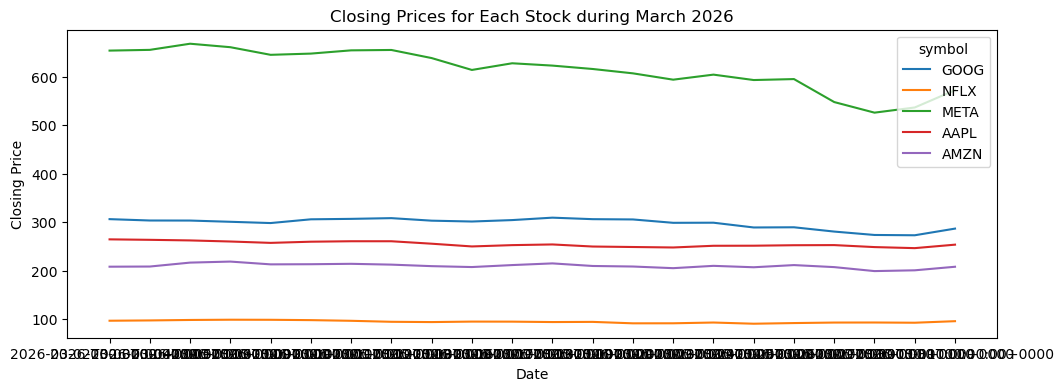

In [8]:
#a)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (12, 4))
sns.lineplot(data = df, x = 'date', y = 'close', hue = 'symbol')
plt.title('Closing Prices for Each Stock during March 2026')
plt.ylabel('Closing Price')
plt.xlabel('Date')
plt.show()

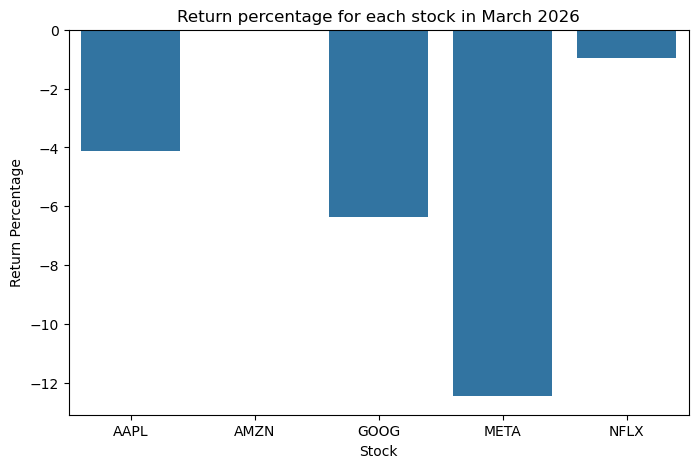

In [10]:
#b)
plt.figure(figsize = (8, 5))
sns.barplot(x = return_percentage.index, y = return_percentage.values)
plt.title("Return percentage for each stock in March 2026")
plt.ylabel('Return Percentage')
plt.xlabel('Stock')
plt.show()

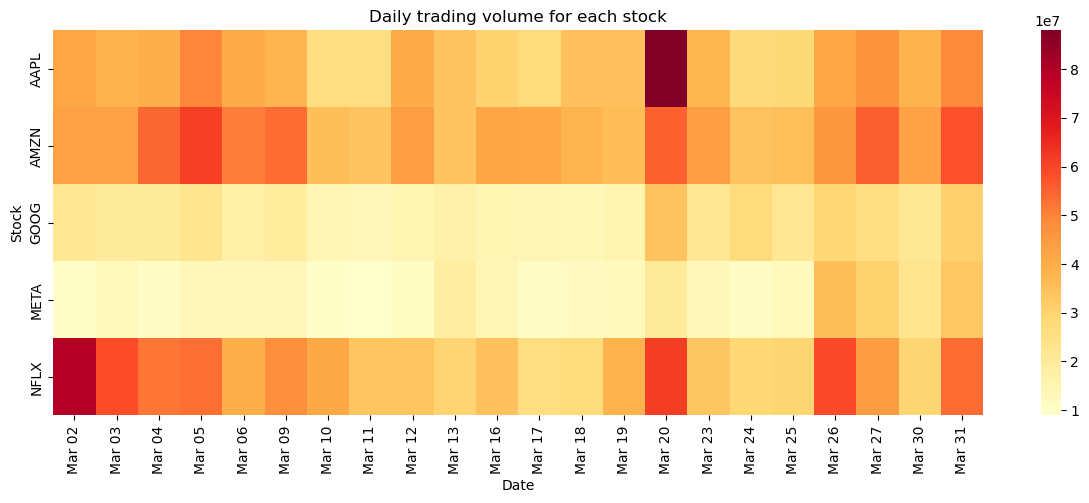

In [13]:
#c)
df['date'] = pd.to_datetime(df['date']).dt.strftime('%b %d')
df_volume = df.pivot(index = 'symbol', columns = 'date', values = 'volume')


plt.figure(figsize = (15, 5))
sns.heatmap(df_volume, cmap = 'YlOrRd')
plt.title('Daily trading volume for each stock')
plt.ylabel('Stock')
plt.xlabel('Date')
plt.show()

### Task 4: Exporting and importing data (1p)

a) Export the JSON data retrieved in Task 2a as a JSON file `stockdata.json` into a subfolder called `exports`.

b) Export the DataFrame from Task 2b as a CSV file `stockdata.csv` into the same `exports` subfolder.

c) Load back the exported data from both a) and b). Print the first five rows of each and verify that the data looks identical to what it was in Task 2.

In [15]:
#a)
import os
import json

os.makedirs("exports", exist_ok = True)
with open("exports/stockdata.json", "w") as f:
    json.dump(all_data, f, indent = 4)

In [16]:
#b)
df.to_csv("exports/stockdata.csv", index = False)

In [18]:
#c)
#loading stockdata.json file
with open("exports/stockdata.json", "r") as f:
    data_json = json.load(f)

#loading stockdata.csv file
data_csv = pd.read_csv("exports/stockdata.csv")

#printing first five rows of each
print(data_json[:5])
print(data_csv.head())

[{'open': 549.98, 'high': 573.69, 'low': 546.77, 'close': 572.13, 'volume': 32809500.0, 'adj_high': 573.69, 'adj_low': 546.77, 'adj_close': 572.13, 'adj_open': 549.98, 'adj_volume': 32898272.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'META', 'exchange': 'ARCX', 'date': '2026-03-31T00:00:00+0000'}, {'open': 536.38, 'high': 539.55, 'low': 528.54, 'close': 536.38, 'volume': 22758800.0, 'adj_high': 539.55, 'adj_low': 528.54, 'adj_close': 536.38, 'adj_open': 536.38, 'adj_volume': 22795203.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'META', 'exchange': 'ARCX', 'date': '2026-03-30T00:00:00+0000'}, {'open': 540.1, 'high': 543.6, 'low': 520.26, 'close': 525.72, 'volume': 29980300.0, 'adj_high': 543.5999, 'adj_low': 520.26, 'adj_close': 525.72, 'adj_open': 540.1, 'adj_volume': 30133010.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'META', 'exchange': 'ARCX', 'date': '2026-03-27T00:00:00+0000'}, {'open': 582.49, 'high': 583.0, 'low': 543.35, 'close': 547.54, 'volume': 35664700

### Task 5: Querying the Northwind database (1p)

Download an SQLite version of Microsoft's Northwind database (from [https://github.com/jpwhite3/northwind-SQLite3](https://github.com/jpwhite3/northwind-SQLite3), press the Download Here button). Connect to the database using `sqlite3`.

a) Connect to the database and list all tables it contains (print the table names).

b) Write a SQL query that retrieves all products with a unit price above 30, showing `ProductName`, `UnitPrice`, and `UnitsInStock`. Load the result into a DataFrame and print it.

c) Write a SQL query that joins the `Orders`, `Customers`, and `Order Details` tables to show `CompanyName`, `OrderID`, `OrderDate`, `ShipCountry`, and the line total (`UnitPrice * Quantity`) for all orders shipped to Germany. Load the result into a DataFrame and print it. Note, order details needs to be written as 'Order Details' within the quotation marks in the query since it consists of two words as the table name.

Hint: The SQL query in 5c should look something like this:

```
    SELECT columnNameX,
           columnNameX,
           columnNameX,
           columnNameX,
           columnNameX * columnNameX AS LineTotal
    FROM SomeTable o
    JOIN SomeTable c ON SomeTable.id = OtherTable.id
    JOIN SomeTable od ON SomeTable.id = OtherTable.id
    WHERE columnName = countryName
```

Hint: If you are unfamiliar with SQL, using AI to write the queries is a good idea. Remember to verify though that the column and table names are correct and not hallucinated. Microsoft Copilot is usually very bad so I suggest using Claude, ChatGPT or Le Chat.

In [21]:
#a)
import sqlite3
connection = sqlite3.connect("northwind.db")
db = connection.cursor()

db.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = db.fetchall()

for table in tables:
    print(table[0])

Categories
sqlite_sequence
CustomerCustomerDemo
CustomerDemographics
Customers
Employees
EmployeeTerritories
Order Details
Orders
Products
Regions
Shippers
Suppliers
Territories


In [27]:
#b)
product_over30 = db.execute(
    """
    SELECT ProductName, UnitPrice, UnitsInStock  
    FROM Products 
    WHERE UnitPrice > 30
    """
).fetchall()

df_products = pd.DataFrame(product_over30, columns = ["ProductName", "UnitPrice", "UnitsInStock"])

display(df_products)

,ProductName,UnitPrice,UnitsInStock
0,Northwoods Cranberry Sauce,40.00,6
1,Mishi Kobe Niku,97.00,29
2,Ikura,31.00,31
3,Queso Manchego La Pastora,38.00,86
4,Alice Mutton,39.00,0
5,Carnarvon Tigers,62.50,42
6,Sir Rodney's Marmalade,81.00,40
7,Gumbär Gummibärchen,31.23,15
8,Schoggi Schokolade,43.90,49
9,Rössle Sauerkraut,45.60,26


In [32]:
#c)
result = db.execute(
    """
    SELECT Customers.CompanyName,
        Orders.OrderID,
        Orders.OrderDate,
        Orders.ShipCountry,
        'Order Details'.UnitPrice * 'Order Details'.Quantity AS Total
    FROM Orders
    JOIN Customers ON Orders.CustomerID = Customers.CustomerID
    JOIN 'Order Details' ON Orders.OrderID = 'Order Details'. OrderID
    WHERE Orders.ShipCountry = 'Germany'
    """
).fetchall()

df_germany = pd.DataFrame(result, columns = ["CompanyName", "OrderID", "OrderDate", "ShipCountry", "Total"])
display(df_germany)

,CompanyName,OrderID,OrderDate,ShipCountry,Total
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0
...,...,...,...,...,...
80668,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,864.0
80669,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,735.0
80670,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,75.0
80671,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,500.0


### Task 6: Visualizing Northwind data (1p)

Using the query results from Task 5, create the following visualizations:

a) Using the result from Task 5c, create a bar plot showing the number of orders per customer (for the top 10 customers who shipped to Germany).

b) Using the result from Task 5c, compute the total sales per order date and create a density plot (KDE plot) of daily total sales for orders shipped to Germany. The density plot shows the distribution of sales volumes, i.e., makes it easy to see the typical size of daily sales volumes.

c) Write a new SQL query that joins `OrderDetails`, `Products`, and `Categories` using inner joins to compute the total revenue (`UnitPrice * Quantity`) per product category. Load the result into a DataFrame and create a bar plot showing total revenue by category.

Hint: The SQL query in 6c should look something like this:

```
    SELECT columnName1,
           SUM(columnName2 * columnName3) AS newColumnName
    FROM table1 od
    JOIN table2 p ON table1_id = table2_id
    JOIN table3 cat ON table2_id = table3_id
    GROUP BY columnName1
```

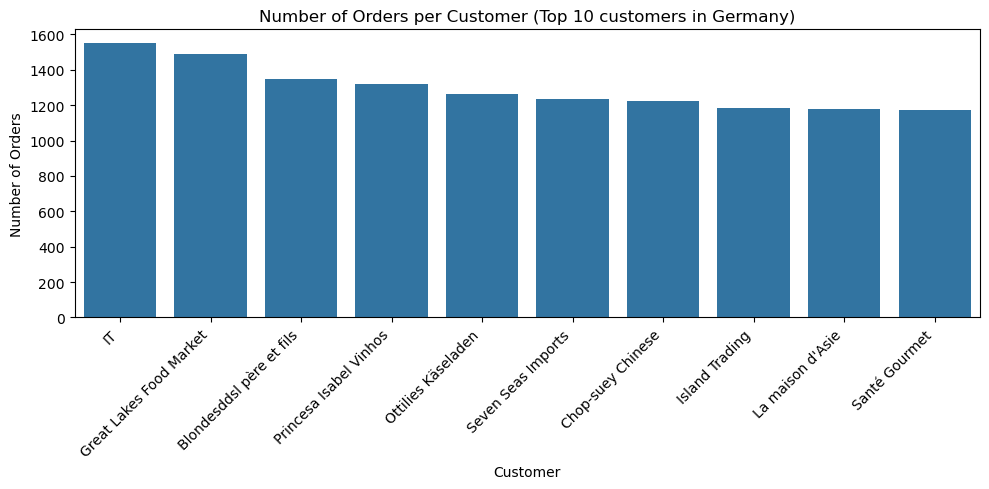

In [34]:
#a)
top10_customers = df_germany.groupby("CompanyName")["OrderID"].count().nlargest(10)

plt.figure(figsize = (10, 5))
sns.barplot(x = top10_customers.index, y = top10_customers.values)
plt.title("Number of Orders per Customer (Top 10 customers in Germany)")
plt.ylabel("Number of Orders")
plt.xlabel("Customer")
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

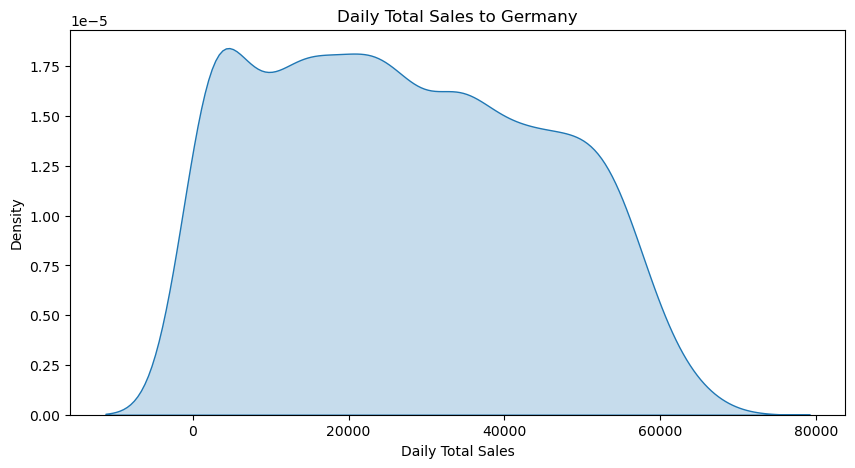

In [36]:
#b)
total_daily_sales = df_germany.groupby("OrderDate")["Total"].sum()

plt.figure(figsize = (10, 5))
sns.kdeplot(total_daily_sales, fill = True)
plt.title("Daily Total Sales to Germany")
plt.ylabel("Density")
plt.xlabel("Daily Total Sales")
plt.show()


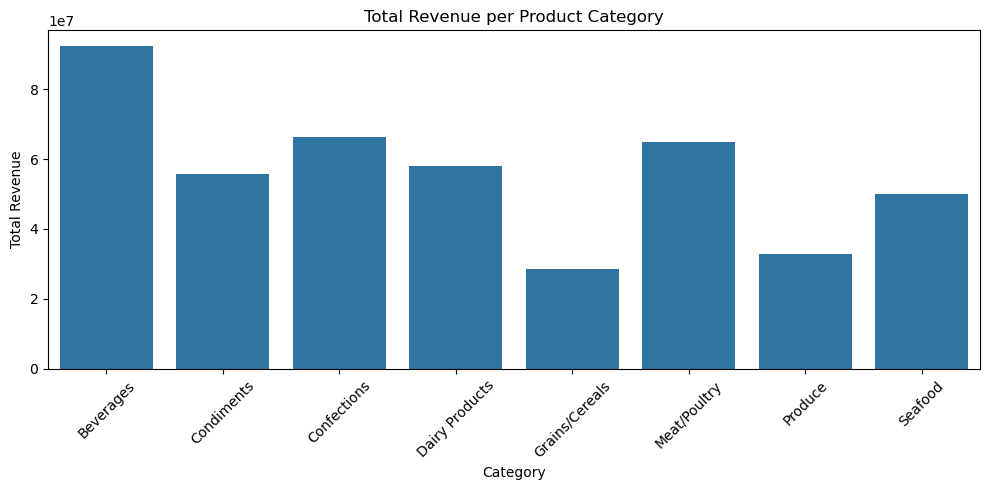

In [40]:
#c)
revenue_category = db.execute(
    """
    SELECT Categories.CategoryName,
            SUM('Order Details'.UnitPrice * 'Order Details'.Quantity) AS TotalRevenue
    FROM 'Order Details'
    JOIN Products ON 'Order Details'.ProductID = Products.ProductID
    JOIN Categories ON Products.CategoryID = Categories.CategoryID
    GROUP BY Categories.CategoryName
    """
).fetchall()

#loading into a dataframe
df_revenue_categories = pd.DataFrame(revenue_category, columns = ["CategoryName", "TotalRevenue"])

#creating bar plot
plt.figure(figsize = (10, 5))
sns.barplot(data = df_revenue_categories, x = "CategoryName", y = "TotalRevenue")
plt.title("Total Revenue per Product Category")
plt.ylabel("Total Revenue")
plt.xlabel("Category")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

### Task 7: Comparing Python to SQL (1p)

a) Write a SQL query that retrieves the full `Products` table and the full `Categories` table into separate DataFrames. Print the first 5 rows of each.

b) Using pandas, perform an inner join on the two DataFrames from 7a on `CategoryID`.

c) Replicate with Python the SQL code of Task 6c, retrieving first the tables fully using SQL and joining them with pandas. Using `%%time` or `time.time()`, compare the execution speed of performing the join fully with SQL (as in 6c) versus performing it in Python with pandas after retrieving via SQL the tables only (similar to what was done in Task 7a-b). Print both execution times and briefly comment on which was faster.

In [46]:
#a)
products_table = db.execute("SELECT * FROM Products").fetchall()
df_products = pd.DataFrame(products_table, columns = [desc[0] for desc in db.description])

categories_table = db.execute("SELECT * FROM Categories").fetchall()
df_categories = pd.DataFrame(categories_table, columns = [desc[0] for desc in db.description])

print("df_products first 5 rows:")
print(df_products.head())
print()
print()

print("df_categories first 5 rows:")
print(df_categories.head())


df_products first 5 rows:
   ProductID                   ProductName  SupplierID  CategoryID  \
0          1                          Chai           1           1   
1          2                         Chang           1           1   
2          3                 Aniseed Syrup           1           2   
3          4  Chef Anton's Cajun Seasoning           2           2   
4          5        Chef Anton's Gumbo Mix           2           2   

       QuantityPerUnit  UnitPrice  UnitsInStock  UnitsOnOrder  ReorderLevel  \
0   10 boxes x 20 bags      18.00            39             0            10   
1   24 - 12 oz bottles      19.00            17            40            25   
2  12 - 550 ml bottles      10.00            13            70            25   
3       48 - 6 oz jars      22.00            53             0             0   
4             36 boxes      21.35             0             0             0   

  Discontinued  
0            0  
1            0  
2            0  
3         

In [49]:
#b
import pandas as pd
inner_join = pd.merge(df_products, df_categories, on="CategoryID", how="inner")
display(inner_join)

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,73,Röd Kaviar,17,8,24 - 150 g jars,15.00,101,0,5,0,Seafood,Seaweed and fish,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
73,74,Longlife Tofu,4,7,5 kg pkg.,10.00,4,20,5,0,Produce,Dried fruit and bean curd,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
74,75,Rhönbräu Klosterbier,12,1,24 - 0.5 l bottles,7.75,125,0,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
75,76,Lakkalikööri,23,1,500 ml,18.00,57,0,20,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [58]:
#c)
import time

#timing the sql approach
start_sql = time.time()

revenue_category = db.execute(
    """
    SELECT Categories.CategoryName,
            SUM('Order Details'.UnitPrice * 'Order Details'.Quantity) AS TotalRevenue
    FROM 'Order Details'
    JOIN Products ON 'Order Details'.ProductID = Products.ProductID
    JOIN Categories ON Products.CategoryID = Categories.CategoryID
    GROUP BY Categories.CategoryName
    """
).fetchall()

df_revenue_categories = pd.DataFrame(revenue_category, columns = ["CategoryName", "TotalRevenue"])

end_sql = time.time()
sql_time = end_sql - start_sql


#Pandas approach
start_pandas = time.time()

order_details_table = db.execute("SELECT * FROM 'Order Details'").fetchall()
df_order_details = pd.DataFrame(order_details_table, columns = [desc[0] for desc in db.description])

products_table = db.execute("SELECT * FROM Products").fetchall()
df_products = pd.DataFrame(products_table, columns = [desc[0] for desc in db.description])

categories_table = db.execute("SELECT * FROM Categories").fetchall()
df_categories = pd.DataFrame(categories_table, columns = [desc[0] for desc in db.description])

inner_products_orderdetails = pd.merge(df_order_details, df_products, on="ProductID", how="inner")
inner_merged = pd.merge(inner_products_orderdetails, df_categories, on="CategoryID", how="inner")
inner_merged['TotalRevenue'] = inner_merged['UnitPrice_x'] * inner_merged['Quantity']
df_final = inner_merged.groupby('CategoryName')['TotalRevenue'].sum().reset_index()

end_pandas = time.time()
pandas_time = end_pandas - start_pandas

print(df_revenue_categories)
display(df_final) #for visualisation

print(f"SQL time: {sql_time} seconds")
print(f"Pandas time: {pandas_time} seconds")
if sql_time < pandas_time:
    print("SQL is faster.")
else:
    print("Pandas is faster.")


     CategoryName  TotalRevenue
0       Beverages   92181842.95
1      Condiments   55802774.45
2     Confections   66347544.94
3  Dairy Products   58034940.00
4  Grains/Cereals   28573512.55
5    Meat/Poultry   64896314.41
6         Produce   32706403.90
7         Seafood   49931965.52


,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Condiments,55802774.45
2,Confections,66347544.94
3,Dairy Products,58034940.00
4,Grains/Cereals,28573512.55
5,Meat/Poultry,64896314.41
6,Produce,32706403.90
7,Seafood,49931965.52


SQL time: 0.5870637893676758 seconds
Pandas time: 1.8346519470214844 seconds
SQL is faster.


### Task 8: Wide and long format (1p)

You are given two datasets. The first is in wide format:

```python
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})
```

The second is in long format:

```python
long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})
```

a) Convert `wide_data` from wide to long format using `pd.melt()`. Print the DataFrame before and after conversion.

b) Convert `long_data` from long to wide format using `.pivot()`. Print the DataFrame before and after conversion.

c) Convert both transformed datasets back to their original format. Print the datasets before and after to confirm they match the originals.

In [66]:
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})
long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

#a)
print(wide_data)
wide_to_long = pd.melt(wide_data, id_vars = "store", value_vars = ["Q1_sales", "Q2_sales", "Q3_sales", "Q4_sales"], var_name = "quarter", value_name = "sales")
print()
print(wide_to_long)

      store  Q1_sales  Q2_sales  Q3_sales  Q4_sales
0  Helsinki     12000     13500     11800     15000
1   Tampere      8500      9100      8800     10200
2     Turku      9200      9800     10100     11500

       store   quarter  sales
0   Helsinki  Q1_sales  12000
1    Tampere  Q1_sales   8500
2      Turku  Q1_sales   9200
3   Helsinki  Q2_sales  13500
4    Tampere  Q2_sales   9100
5      Turku  Q2_sales   9800
6   Helsinki  Q3_sales  11800
7    Tampere  Q3_sales   8800
8      Turku  Q3_sales  10100
9   Helsinki  Q4_sales  15000
10   Tampere  Q4_sales  10200
11     Turku  Q4_sales  11500


In [71]:
#b)
print(long_data)
print()

long_to_wide = long_data.pivot(index = "month", columns = "product", values = "units_sold").rename_axis(columns=None).reset_index()
print(long_to_wide)

  month product  units_sold
0   Jan  Laptop          45
1   Jan   Phone         120
2   Feb  Laptop          50
3   Feb   Phone         110
4   Mar  Laptop          55
5   Mar   Phone         130

  month  Laptop  Phone
0   Feb      50    110
1   Jan      45    120
2   Mar      55    130


In [78]:
#c)
print(wide_to_long)
print()
wide_to_wide = wide_to_long.pivot(index = "store", columns = "quarter", values = "sales").rename_axis(columns=None).reset_index()
print(wide_to_wide) #looks the same as in the beginning


print()
print(long_to_wide)
print()
long_to_long = pd.melt(long_to_wide, id_vars = "month", var_name = "product", value_name = "units_sold")
month_order = ["Jan", "Feb", "Mar"]   #month order has to be restored so that rows are displayed in month order
long_to_long["month"] = pd.Categorical(long_to_long["month"], categories=month_order, ordered=True)
long_to_long = long_to_long.sort_values("month").reset_index(drop=True)

print(long_to_long)




       store   quarter  sales
0   Helsinki  Q1_sales  12000
1    Tampere  Q1_sales   8500
2      Turku  Q1_sales   9200
3   Helsinki  Q2_sales  13500
4    Tampere  Q2_sales   9100
5      Turku  Q2_sales   9800
6   Helsinki  Q3_sales  11800
7    Tampere  Q3_sales   8800
8      Turku  Q3_sales  10100
9   Helsinki  Q4_sales  15000
10   Tampere  Q4_sales  10200
11     Turku  Q4_sales  11500

      store  Q1_sales  Q2_sales  Q3_sales  Q4_sales
0  Helsinki     12000     13500     11800     15000
1   Tampere      8500      9100      8800     10200
2     Turku      9200      9800     10100     11500

  month  Laptop  Phone
0   Feb      50    110
1   Jan      45    120
2   Mar      55    130

  month product  units_sold
0   Jan  Laptop          45
1   Jan   Phone         120
2   Feb  Laptop          50
3   Feb   Phone         110
4   Mar  Laptop          55
5   Mar   Phone         130
